
#Домашняя работа по "Семинар: классический NLP-пайплайн (spaCy) + Zipf + правила" выполнил Зейналов У.Р.

In [1]:
# (Colab) Установка зависимостей
!pip -q install spacy==3.7.5
!python -m spacy download ru_core_news_sm -q
!pip -q install nltk


✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


#1. Возьмите фрагмент русского романа
##1.1 Загрузка данных с Lib.ru / Произведение "Письма Баламута" на русском языке


In [2]:

import re
from collections import Counter
import requests


URL = "https://www.lib.ru/TALES/LEWIS_C_S/screwtape.txt"

raw = requests.get(URL, timeout=30).text

match = re.search(r"\bвступление\b", raw, re.IGNORECASE)

if match:
    text = raw[match.start():]
else:
    text = raw

print("Длина текста (символов):", len(text))
print(text[:400])


Длина текста (символов): 169266
ВСТУПЛЕНИЕ</h2></ul>
     Я не собираюсь объяснять, как в мои руки попала та переписка, которую я
теперь предлагаю вниманию общества.
     Есть два равносильных и противоположных заблуждения относительно бесов.
Одни не верят в них, другие верят и  питают  к  ним  ненужный  и  нездоровый
интерес.  Сами бесы рады обеим ошибкам и с одинаковым восторгом приветствуют
и материалиста, и любителя черной м


#2. Сравните частоты по токенам, по стеммам, по леммам
##2.1 Токенизация, types/tokens, частоты

In [3]:

# Простая токенизация для частот: слова из латинских букв + апострофы
tokens = re.findall(r"[А-Яа-я]+(?:'[А-Яа-я]+)?", text.lower())
cnt = Counter(tokens)

N_tokens = sum(cnt.values())  # tokens = все употребления
V_types = len(cnt)            # types  = уникальные слова

print(f"Tokens (всего словоупотреблений): {N_tokens:,}")
print(f"Types  (уникальных слов):        {V_types:,}")

# Топ-20
top20 = cnt.most_common(20)
top20[:10]


Tokens (всего словоупотреблений): 24,189
Types  (уникальных слов):        7,265


[('и', 823),
 ('в', 616),
 ('что', 505),
 ('не', 434),
 ('он', 413),
 ('его', 304),
 ('на', 238),
 ('как', 219),
 ('к', 214),
 ('ты', 190)]

##2.2 Zipf: rank–frequency (log–log) + топ-20 + длинный хвост ≤ 3

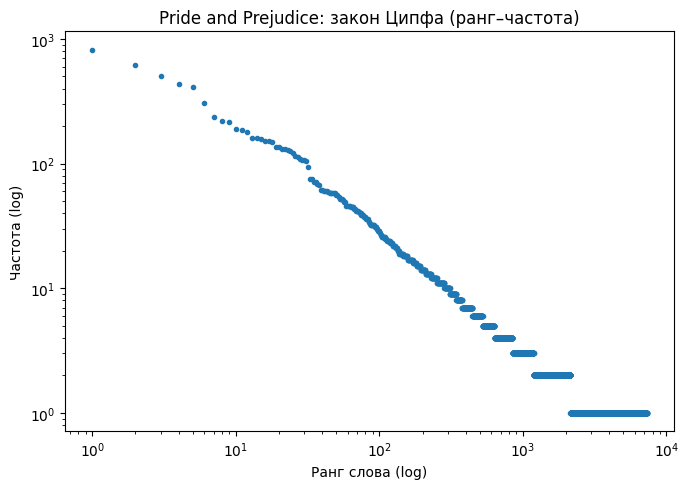

['абсолютно',
 'причинять',
 'мгновение',
 'господствует',
 'завладеть',
 'молодых',
 'трать',
 'исправляет',
 'возложенным',
 'добраться']

In [4]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import spacy
from nltk.stem.snowball import SnowballStemmer

# Zipf данные
freqs_sorted = np.array(sorted(cnt.values(), reverse=True))
ranks = np.arange(1, len(freqs_sorted) + 1)

# 3.1 Zipf log-log
plt.figure(figsize=(7,5))
plt.loglog(ranks, freqs_sorted, marker=".", linestyle="none")
plt.title("Pride and Prejudice: закон Ципфа (ранг–частота)")
plt.xlabel("Ранг слова (log)")
plt.ylabel("Частота (log)")
plt.tight_layout()
plt.show()

# 3.3 Длинный хвост: <= 3


# 3.4 (Опционально) 10 случайных hapax (c=1)
hapax = [w for w, c in cnt.items() if c == 1]
rng = np.random.default_rng(0)
sample10 = list(rng.choice(hapax, size=10, replace=False))
sample10


##2.3 Стеммы

In [5]:
stemmer = SnowballStemmer("russian")

stems = [stemmer.stem(t) for t in tokens]
stem_cnt = Counter(stems)

N_stems = sum(stem_cnt.values())
V_stems = len(stem_cnt)

print("STEMS")
print("Tokens:", N_stems)
print("Types:", V_stems)

stem_top20 = stem_cnt.most_common(20)
stem_top20

STEMS
Tokens: 24189
Types: 4074


[('и', 823),
 ('в', 616),
 ('он', 616),
 ('что', 505),
 ('не', 454),
 ('эт', 386),
 ('ег', 304),
 ('как', 291),
 ('на', 239),
 ('к', 214),
 ('котор', 205),
 ('ты', 190),
 ('а', 185),
 ('так', 181),
 ('все', 164),
 ('с', 161),
 ('мы', 161),
 ('от', 160),
 ('враг', 155),
 ('то', 152)]

##2.4 Леммы


In [6]:
nlp = spacy.load("ru_core_news_sm")

doc = nlp(" ".join(tokens))
lemmas = [t.lemma_ for t in doc if t.is_alpha]

lemma_cnt = Counter(lemmas)

N_lemmas = sum(lemma_cnt.values())
V_lemmas = len(lemma_cnt)

print("LEMMAS")
print("Tokens:", N_lemmas)
print("Types:", V_lemmas)

lemma_top20 = lemma_cnt.most_common(20)
lemma_top20

LEMMAS
Tokens: 24189
Types: 4559


[('и', 823),
 ('в', 672),
 ('он', 559),
 ('что', 545),
 ('не', 434),
 ('это', 256),
 ('на', 238),
 ('человек', 236),
 ('к', 221),
 ('как', 219),
 ('ты', 190),
 ('а', 185),
 ('они', 178),
 ('с', 161),
 ('мы', 161),
 ('быть', 160),
 ('от', 160),
 ('его', 158),
 ('я', 151),
 ('если', 150)]

##2.5 Сравнение топ 20


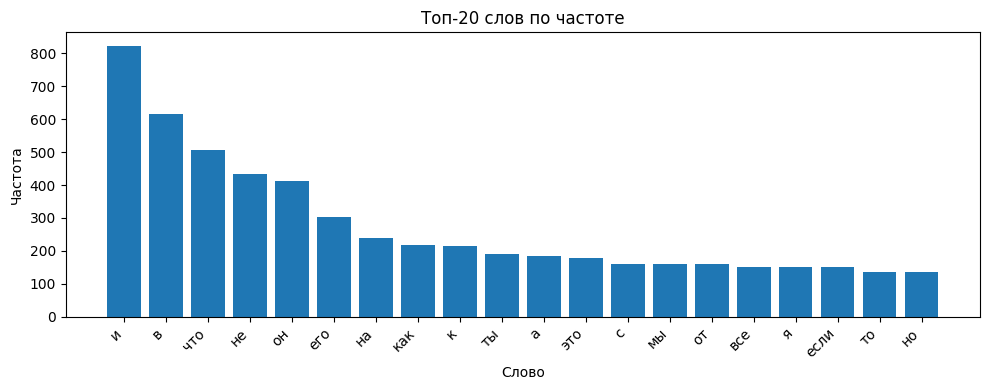

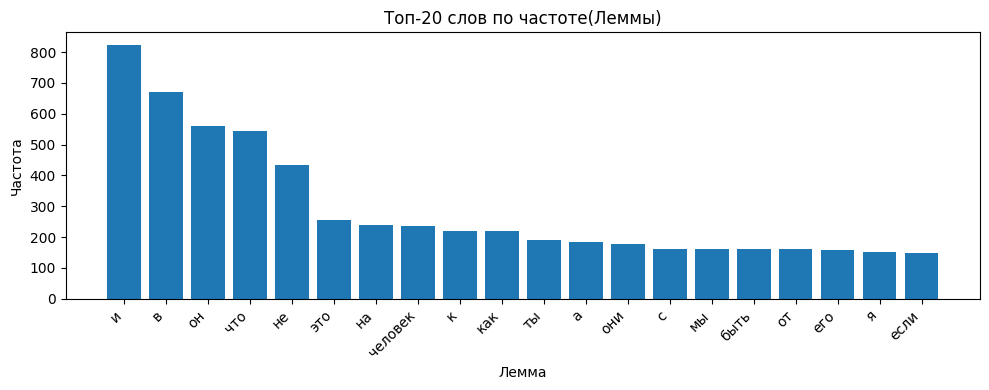

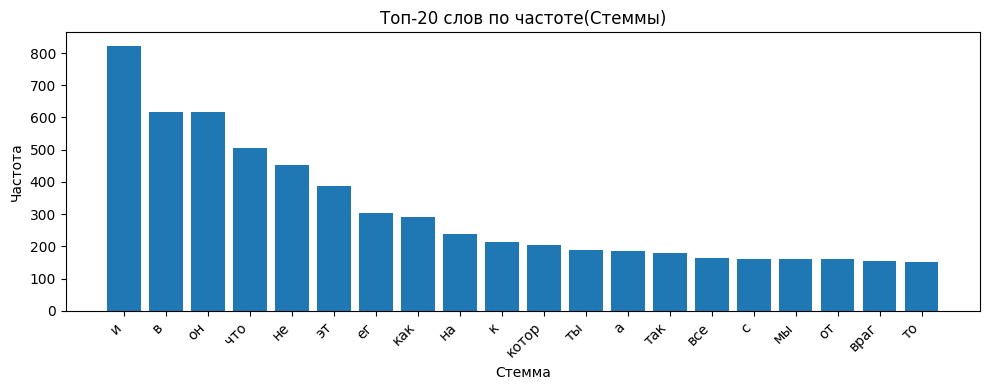

Хвост (c<=3): 6419 типов = 88.4% словаря
Хвост (c<=3): 8058 токенов = 33.3% текста


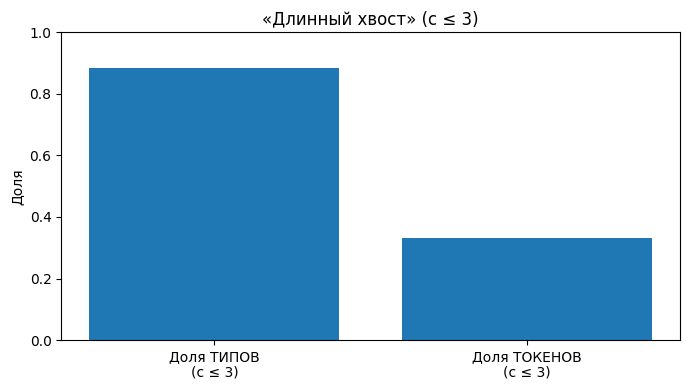

Хвост Стемма: 3154 типов = 77.4% словаря
Хвост Стемма: 4451 токенов = 18.4% текста


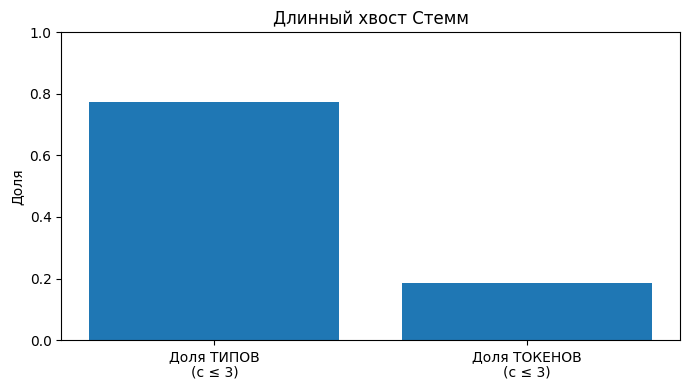

Хвост Стемма: 3626 типов = 79.5% словаря
Хвост Стемма: 4926 токенов = 20.4% текста


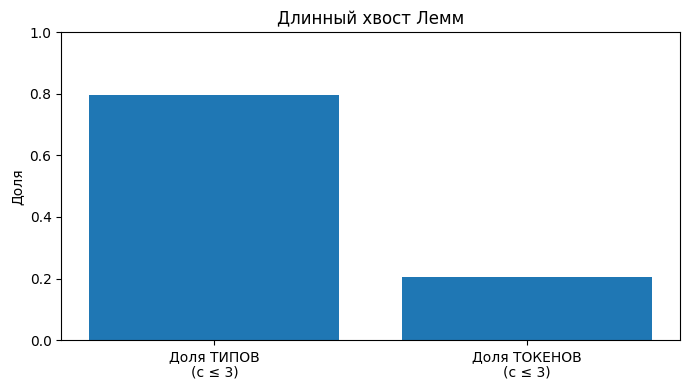

In [7]:
#Топ-20
df_top20 = pd.DataFrame(top20, columns=["word","count"])
plt.figure(figsize=(10,4))
plt.bar(df_top20["word"], df_top20["count"])
plt.title("Топ-20 слов по частоте")
plt.xlabel("Слово")
plt.ylabel("Частота")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Top-20 Лемм
df_top20_lemma = pd.DataFrame(lemma_cnt.most_common(20), columns=["lemma","count"])

plt.figure(figsize=(10,4))
plt.bar(df_top20_lemma["lemma"], df_top20_lemma["count"])
plt.title("Топ-20 слов по частоте(Леммы)")
plt.xlabel("Лемма")
plt.ylabel("Частота")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Top-20 Стемм
df_top20_stem = pd.DataFrame(stem_cnt.most_common(20), columns=["stem","count"])
plt.figure(figsize=(10,4))
plt.bar(df_top20_stem["stem"], df_top20_stem["count"])
plt.title("Топ-20 слов по частоте(Стеммы)")
plt.xlabel("Стемма")
plt.ylabel("Частота")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

tail_words = [w for w, c in cnt.items() if c <= 3]
tail_types = len(tail_words)
tail_tokens = sum(cnt[w] for w in tail_words)

print(f"Хвост (c<=3): {tail_types} типов = {tail_types/V_types:.1%} словаря")
print(f"Хвост (c<=3): {tail_tokens} токенов = {tail_tokens/N_tokens:.1%} текста")

plt.figure(figsize=(7,4))
plt.bar(["Доля ТИПОВ\n(c ≤ 3)", "Доля ТОКЕНОВ\n(c ≤ 3)"],
        [tail_types/V_types, tail_tokens/N_tokens])
plt.ylim(0, 1)
plt.title("«Длинный хвост» (c ≤ 3)")
plt.ylabel("Доля")
plt.tight_layout()
plt.show()

stem_tail_words = [w for w, c in stem_cnt.items() if c <= 3]
stem_tail_types = len(stem_tail_words)
stem_tail_tokens = sum(stem_cnt[w] for w in stem_tail_words)

plt.figure(figsize=(7,4))
plt.bar(["Доля ТИПОВ\n(c ≤ 3)", "Доля ТОКЕНОВ\n(c ≤ 3)"],
        [stem_tail_types/V_stems, stem_tail_tokens/N_stems])

stem_tail_types = len([w for w,c in stem_cnt.items() if c <= 3])
stem_tail_tokens = sum(c for w,c in stem_cnt.items() if c <= 3)

print(f"Хвост Стемма: {stem_tail_types} типов = {stem_tail_types/V_stems:.1%} словаря")
print(f"Хвост Стемма: {stem_tail_tokens} токенов = {stem_tail_tokens/N_stems:.1%} текста")

plt.ylim(0,1)
plt.title("Длинный хвост Стемм")
plt.ylabel("Доля")
plt.tight_layout()
plt.show()

lemma_tail_types = len([w for w,c in lemma_cnt.items() if c <= 3])
lemma_tail_tokens = sum(c for w,c in lemma_cnt.items() if c <= 3)

print(f"Хвост Стемма: {lemma_tail_types} типов = {lemma_tail_types/V_lemmas:.1%} словаря")
print(f"Хвост Стемма: {lemma_tail_tokens} токенов = {lemma_tail_tokens/N_lemmas:.1%} текста")

lemma_tail_words = [w for w, c in lemma_cnt.items() if c <= 3]
lemma_tail_types = len(lemma_tail_words)
lemma_tail_tokens = sum(lemma_cnt[w] for w in lemma_tail_words)

plt.figure(figsize=(7,4))
plt.bar(["Доля ТИПОВ\n(c ≤ 3)", "Доля ТОКЕНОВ\n(c ≤ 3)"],
        [lemma_tail_types/V_lemmas, lemma_tail_tokens/N_lemmas])

plt.ylim(0,1)
plt.title("Длинный хвост Лемм")
plt.ylabel("Доля")
plt.tight_layout()
plt.show()


##2.6 Классический NLP-пайплайн в spaCy

In [8]:

import spacy

nlp = spacy.load("ru_core_news_sm")

doc = nlp("Мой дорогой Гнусик! Весьма досадно было узнать, что твой подопечный обратился. Я всё ещё надеюсь, что ты поймёшь, как легко сбить человека с пути. Твой любящий дядя Баламут!")
print("SENTENCES:", [s.text for s in doc.sents])
print("TOKENS:", [t.text for t in doc])
print("POS:", [(t.text, t.pos_) for t in doc])
print("DEP:", [(t.text, t.dep_, t.head.text) for t in doc])

print("\nNER entities:")
for ent in doc.ents:
    print(ent.text, ent.label_)

for t in doc:
    print(f"{t.i:2d}  {t.text!r:12}  is_alpha={t.is_alpha}  is_punct={t.is_punct}")


SENTENCES: ['Мой дорогой Гнусик!', 'Весьма досадно было узнать, что твой подопечный обратился.', 'Я всё ещё надеюсь, что ты поймёшь, как легко сбить человека с пути.', 'Твой любящий дядя Баламут!']
TOKENS: ['Мой', 'дорогой', 'Гнусик', '!', 'Весьма', 'досадно', 'было', 'узнать', ',', 'что', 'твой', 'подопечный', 'обратился', '.', 'Я', 'всё', 'ещё', 'надеюсь', ',', 'что', 'ты', 'поймёшь', ',', 'как', 'легко', 'сбить', 'человека', 'с', 'пути', '.', 'Твой', 'любящий', 'дядя', 'Баламут', '!']
POS: [('Мой', 'DET'), ('дорогой', 'ADJ'), ('Гнусик', 'PROPN'), ('!', 'PUNCT'), ('Весьма', 'ADV'), ('досадно', 'ADJ'), ('было', 'AUX'), ('узнать', 'VERB'), (',', 'PUNCT'), ('что', 'SCONJ'), ('твой', 'DET'), ('подопечный', 'NOUN'), ('обратился', 'VERB'), ('.', 'PUNCT'), ('Я', 'PRON'), ('всё', 'PART'), ('ещё', 'ADV'), ('надеюсь', 'VERB'), (',', 'PUNCT'), ('что', 'SCONJ'), ('ты', 'PRON'), ('поймёшь', 'VERB'), (',', 'PUNCT'), ('как', 'ADV'), ('легко', 'ADV'), ('сбить', 'VERB'), ('человека', 'NOUN'), ('с', '

##2.7 Применим пайплайн к реальному фрагменту из книги

In [9]:

# Возьмём небольшой фрагмент (чтобы быстро работало)
snippet = " ".join(text.split()[1:350])  # первые ~350 слов
doc = nlp(snippet)

# Посмотрим 15 токенов с POS/леммой
rows = []
for t in list(doc)[:15]:
    rows.append([t.text, t.lemma_, t.pos_, t.tag_])
pd.DataFrame(rows, columns=["token","lemma","POS","TAG"])


,token,lemma,POS,TAG
0,Я,я,PRON,PRON
1,не,не,PART,PART
2,собираюсь,собираться,VERB,VERB
3,объяснять,объяснять,VERB,VERB
4,",",",",PUNCT,PUNCT
5,как,как,ADV,ADV
6,в,в,ADP,ADP
7,мои,мой,DET,DET
8,руки,рука,NOUN,NOUN
9,попала,попасть,VERB,VERB


#3. Выберите 5 предложений и сравните
##3.1.1 Базовая токенезация / Стемминг / Лематизация

In [10]:
# (Colab) Установка для русского
!pip -q install spacy==3.7.5  nltk
!python -m spacy download ru_core_news_sm -q
!pip install pymorphy3


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 67.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [12]:
import re
import pymorphy3
ru_text = (
    "Мой дорогой Гнусик! Твой любящий дядя Баламут!\n"
    "Весьма досадно было узнать, что твой подопечный обратился.\n"
    "При этом, конечно, никакого значения не имеет, что за люди сидят на скамейках.\n"
    "До сих пор я писал тебе так, словно люди, сидящие на соседних скамьях, не дают никаких разумных поводов к разочарованию.\n"
    "Я всё ещё надеюсь, что ты поймёшь, как легко сбить человека с пути.\n"
)
# Базовая токенизация для русского (буквы + дефис)
ru_tokens = re.findall(r"[А-Яа-яЁё]+(?:-[А-Яа-яЁё]+)?", ru_text.lower())
print("Токены:", ru_tokens)

#Стемминг (Snowball)
import nltk
from nltk.stem.snowball import SnowballStemmer

nltk.download("punkt", quiet=True)
stemmer = SnowballStemmer("russian")

ru_stems = [stemmer.stem(w) for w in ru_tokens]
print("Стемминг:", list(zip(ru_tokens, ru_stems)))
#Леммы
morph = pymorphy3.MorphAnalyzer()

ru_lemmas_pym = [morph.parse(w)[0].normal_form for w in ru_tokens]
print("Лемматизация:",list(zip(ru_tokens, ru_lemmas_pym)))


Токены: ['мой', 'дорогой', 'гнусик', 'твой', 'любящий', 'дядя', 'баламут', 'весьма', 'досадно', 'было', 'узнать', 'что', 'твой', 'подопечный', 'обратился', 'при', 'этом', 'конечно', 'никакого', 'значения', 'не', 'имеет', 'что', 'за', 'люди', 'сидят', 'на', 'скамейках', 'до', 'сих', 'пор', 'я', 'писал', 'тебе', 'так', 'словно', 'люди', 'сидящие', 'на', 'соседних', 'скамьях', 'не', 'дают', 'никаких', 'разумных', 'поводов', 'к', 'разочарованию', 'я', 'всё', 'ещё', 'надеюсь', 'что', 'ты', 'поймёшь', 'как', 'легко', 'сбить', 'человека', 'с', 'пути']
Стемминг: [('мой', 'мо'), ('дорогой', 'дорог'), ('гнусик', 'гнусик'), ('твой', 'тво'), ('любящий', 'любя'), ('дядя', 'дяд'), ('баламут', 'баламут'), ('весьма', 'весьм'), ('досадно', 'досадн'), ('было', 'был'), ('узнать', 'узна'), ('что', 'что'), ('твой', 'тво'), ('подопечный', 'подопечн'), ('обратился', 'обрат'), ('при', 'при'), ('этом', 'эт'), ('конечно', 'конечн'), ('никакого', 'никак'), ('значения', 'значен'), ('не', 'не'), ('имеет', 'имеет')

### 3.1.2 Лемматизация через spaCy (удобно, когда вы и так используете пайплайн)

In [13]:
import spacy
from spacy import displacy

nlp_ru = spacy.load("ru_core_news_sm")

doc_ru = nlp_ru(ru_text)
print([(t.text, t.lemma_, t.pos_) for t in doc_ru if t.is_alpha])

displacy.render(doc_ru, style="dep", jupyter=True, options={"distance": 90})


[('Мой', 'мой', 'DET'), ('дорогой', 'дорогой', 'ADJ'), ('Гнусик', 'гнусик', 'PROPN'), ('Твой', 'твой', 'DET'), ('любящий', 'любить', 'VERB'), ('дядя', 'дядя', 'NOUN'), ('Баламут', 'баламут', 'PROPN'), ('Весьма', 'весьма', 'ADV'), ('досадно', 'досадный', 'ADJ'), ('было', 'было', 'AUX'), ('узнать', 'узнать', 'VERB'), ('что', 'что', 'SCONJ'), ('твой', 'твой', 'DET'), ('подопечный', 'подопечный', 'NOUN'), ('обратился', 'обратиться', 'VERB'), ('При', 'При', 'ADP'), ('этом', 'это', 'PRON'), ('конечно', 'конечно', 'ADV'), ('никакого', 'никакой', 'DET'), ('значения', 'значение', 'NOUN'), ('не', 'не', 'PART'), ('имеет', 'иметь', 'VERB'), ('что', 'что', 'SCONJ'), ('за', 'за', 'ADP'), ('люди', 'человек', 'NOUN'), ('сидят', 'сидеть', 'VERB'), ('на', 'на', 'ADP'), ('скамейках', 'скамейка', 'NOUN'), ('До', 'до', 'ADV'), ('сих', 'сей', 'DET'), ('пор', 'пора', 'NOUN'), ('я', 'я', 'PRON'), ('писал', 'писать', 'VERB'), ('тебе', 'тебе', 'PRON'), ('так', 'так', 'ADV'), ('словно', 'словно', 'SCONJ'), ('люд

##3.2 POS-теги + синтаксические зависимости (DEP) + NER для русского

In [14]:
import pandas as pd

# 3.2.1 POS + морфология
rows = []
for t in doc_ru:
    if t.is_space:
        continue
    rows.append([t.text, t.lemma_, t.pos_, t.tag_, t.morph.to_json()])
pd.DataFrame(rows, columns=["token","lemma","POS","TAG","morph"])


,token,lemma,POS,TAG,morph
0,Мой,мой,DET,DET,Case=Nom|Gender=Masc|Number=Sing
1,дорогой,дорогой,ADJ,ADJ,Case=Nom|Degree=Pos|Gender=Masc|Number=Sing
2,Гнусик,гнусик,PROPN,PROPN,Animacy=Anim|Case=Nom|Gender=Masc|Number=Sing
3,!,!,PUNCT,PUNCT,
4,Твой,твой,DET,DET,Case=Nom|Gender=Masc|Number=Sing
...,...,...,...,...,...
71,сбить,сбить,VERB,VERB,Aspect=Perf|VerbForm=Inf|Voice=Act
72,человека,человек,NOUN,NOUN,Animacy=Anim|Case=Acc|Gender=Masc|Number=Sing
73,с,с,ADP,ADP,
74,пути,путь,NOUN,NOUN,Animacy=Inan|Case=Gen|Gender=Masc|Number=Sing


In [15]:
# 3.2.2 Синтаксические зависимости (DEP): token -> head
dep_rows = []
for t in doc_ru:
    if t.is_space:
        continue
    dep_rows.append([t.text, t.dep_, t.head.text])
pd.DataFrame(dep_rows, columns=["token","dep","head"])


,token,dep,head
0,Мой,det,Гнусик
1,дорогой,amod,Гнусик
2,Гнусик,ROOT,Гнусик
3,!,punct,Гнусик
4,Твой,det,дядя
...,...,...,...
71,сбить,advcl,поймёшь
72,человека,obj,сбить
73,с,case,пути
74,пути,obl,сбить


#4. Составьте список имен персонажей
Так оказалось что в произведение только 2 имени


In [16]:
# 9.3 NER (именованные сущности)
[(ent.text, ent.label_) for ent in doc_ru.ents]


[('Гнусик', 'PER'), ('Баламут', 'PER')]

#5. Найдите как можно больше предложений, где здороваются
Оказывается на протяжение всего произведение в тексте нет ни одного приветсвия ни в какой форме, поэтому ищу фразы связанные с верой(так как произведение религиозное)

In [17]:
from spacy.matcher import Matcher

matcher = Matcher(nlp_ru.vocab)

pattern_adj_noun = [
    {"POS": "ADJ"},
    {"POS": "NOUN"}
]

matcher.add("ADJ_NOUN", [pattern_adj_noun])

sentences = [
"Как  раз  сегодня мне попалось несколько страниц одного верующего писателя, где он рекомендует свою  версию  христианства  на том  основании,  что  такая вера переживет гибель старых культур и рождение новых цивилизаций.",
"А поскольку то,  во что  они старались верить, явная ерунда, им эта вера не дается, и мы можем до бесконечности вращать их  мысли  вокруг  них  самих,  ибо  они  стараются достичь невозможного.",
"Без сомнения, он очень скоро поймет, что  его  собственная  вера  прямо противоположна  той  самонадеянности,  на которой основаны все разговоры его новых друзей."
]

for sent in sentences:

    doc = nlp_ru(sent)

    # проверяем, есть ли слово "вера"
    if any(token.lemma_ == "вера" for token in doc):

        matches = matcher(doc)

        for mid, start, end in matches:
            print("Найдено:", doc[start:end].text)

Найдено: верующего писателя
Найдено: старых культур
Найдено: новых цивилизаций
Найдено: явная ерунда
Найдено: новых друзей


## Мини-задача для семинара (русский)

1) Возьмите фрагмент русского романа (например, 30–100k символов).
2) Сравните частоты **по токенам**, **по стеммам**, **по леммам**:
   - Как меняются топ-20?
   - Как меняется доля “длинного хвоста” (≤3) по **types**?
3) Выберите 5 предложений и сравните:
   - POS/DEP/NER от `spaCy`
   - леммы от `pymorphy3`
4) Составьте список имен персонажей
5) Найдите как можно больше предложений, где здороваются
